In [1]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests
import os

pd.set_option('display.max_columns', None)

## Set working directory to tree_growth_metaanalysis_snmc
os.chdir('../../')

from Inventory_data_processing.Code.config import *
from Inventory_data_processing.Code.inventory_processing_functions import *

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Identify which site to process (`Sequoia` or `TharpsCreek`)

In [2]:
site = 'Sequoia' # Sequoia or TharpsCreek

# Import tree-level data from data archive

In [3]:
# Citation: Das, A.J., 2026, Sequoia National Park tree growth data for thinning and burning study: 
# U.S. Geological Survey data release, https://doi.org/10.5066/P1MHZKJY.


# 1. Define the unique item ID from ScienceBase link
item_id = "699dd98ab66b018a7ec1079a"
metadata_url = f"https://www.sciencebase.gov/catalog/item/{item_id}?format=json"

# 2. Get the metadata JSON
response = requests.get(metadata_url).json()

# 3. Create a dictionary to hold DataFrames
dataframes = {}

# 4. Loop through the files attached to the repository item
if "files" in response:
    for file_info in response["files"]:
        # Filter for CSV files
        if file_info["name"].endswith(".csv"):
            file_name = file_info["name"]
            file_url = file_info["url"]

            print(f"Reading '{file_name}' directly into memory...")

            # pd.read_csv accepts web URLs natively and streams them straight to memory
            dataframes[file_name] = pd.read_csv(file_url)
else:
    print("No files found associated with this item ID.")

# 5. Access dataframes by their filenames
all_trees = dataframes['SequoiaTharpsThinBurnStudy_TreeData.csv']
all_plots = dataframes['SequoiaTharpsThinBurnStudy_PlotData.csv']

Reading 'SequoiaTharpsThinBurnStudy_PlotData.csv' directly into memory...
Reading 'SequoiaTharpsThinBurnStudy_TreeData.csv' directly into memory...


# Preliminary data cleaning and filtering

In [4]:
# Select plots associated with site
if site == 'Sequoia':
    tree_raw = all_trees.loc[all_trees['PLOT'].str.contains('FFS')].copy()
    plot_raw = all_plots.loc[all_plots['Plot'].str.contains('FFS')].copy()
elif site == 'TharpsCreek':
    tree_raw = all_trees.loc[all_trees['PLOT'].isin(['LOLOG', 'UPLOG', 'LOTHAR', 'UPTHAR'])].copy()
    plot_raw = all_plots.loc[all_plots['Plot'].isin(['LOLOG', 'UPLOG', 'LOTHAR', 'UPTHAR'])].copy()
else:
    print('Site does not exist in data.')

In [5]:
# Add a unique tree identifier column

# Unique ID = Plot + Tag
tree_raw['TreeID'] = tree_raw['PLOT'] + '_' + tree_raw['TAGNUMBER'].astype(str)

In [6]:
# Specify columns that contain years or DBH measurements
year_cols = [i for i in tree_raw.columns if 'YEAR' in i] + ['YearFirstRecorded'] + ['MortalityYear']
dbh_cols = [i for i in tree_raw.columns if 'DBH' in i]
dbh_cols, year_cols

(['DBH0',
  'DBH1',
  'DBH2',
  'DBH3',
  'DBH4',
  'DBH5',
  'DBH6',
  'DBH7',
  'DBH8',
  'DBH9',
  'DBHMort'],
 ['YEAR1',
  'YEAR2',
  'YEAR3',
  'YEAR4',
  'YEAR5',
  'YEAR6',
  'YEAR7',
  'YEAR8',
  'YEAR9',
  'YearFirstRecorded',
  'MortalityYear'])

In [7]:
# Check that category types are clean for important columns (look for null or strange values)
for cat in ['PLOT','SppCode', 'IngrowthYear'] + year_cols:
    print(cat)
    print(*tree_raw[cat].unique())
    print(tree_raw[cat].dtype)
print("Total number of plots")
print(len(tree_raw['PLOT'].unique()))
print("Total number of trees")
print(len(tree_raw['TreeID'].unique()))

PLOT
FFS5BURN FFS2BURN FFS6BURN FFS7CONTROL
object
SppCode
PILA CADE ABCO ABMA PIPO QUKE PIJE SEGI
object
IngrowthYear
-99 2022 2004 2021 2023 2008 2019 2020 2007 2015 2017 2018 2016 2010 2011 2014 2006 2013 2012 2003 2005 2009
int64
YEAR1
2001.0 nan
float64
YEAR2
nan 2006.0
float64
YEAR3
nan 2011.0 2012.0
float64
YEAR4
nan 2016.0
float64
YEAR5
nan 2021.0 2013.0
float64
YEAR6
nan
float64
YEAR7
nan
float64
YEAR8
nan
float64
YEAR9
nan
float64
YearFirstRecorded
2001 2022 2004 2021 2023 2008 2019 2020 2007 2015 2017 2018 2016 2010 2011 2014 2006 2013 2005 2012 2009 2003
int64
MortalityYear
2002 2023 2005 2003 -99 2020 2007 2004 2012 2022 2006 2019 2014 2013 2015 2021 2016 2009 2008 2017 2018 2011 2010
int64
Total number of plots
4
Total number of trees
3273


## General data check

Some notes from the data provider (Adrian Das, 4/10/24):

* IngrowthYear-- if the tree was ingrowth (i.e., grew to 1.37m after plot establishment), this is the year it became ingrowth. Recall that ingrowth were only measured annually after 1998. Prior to that they were only added during diameter remeasurement years. -99 indicates we don't know the year the tree reached breast height (which is true for any non ingrowth trees)
* YearFirstRecorded-- first year the tree was tracked. Usually this is the plot establishment or the ingrowth year, but rarely a tree might have been 'missed' and added to the database in a different year
* MortalityYear-- year the tree was found dead. -99 if the tree is still alive
* DBH0-- dbh at ingrowth year. Blank if not an ingrowth
* DBH1 to DBH8: DBH at each measurement year
* Year1 to Year8: Year the given dbh measurement was taken
* DBHMort: Dbh at the year of mortality for trees that died.

For Tharp's Creek, there are a couple of trees for which both IngrowthYear and YearFirstRecorded are -99. I don't take any action on these because the rest of the timeseries are intact. 

In [8]:
# Where does YearFirstRecorded = -99?
tree_raw.loc[tree_raw['YearFirstRecorded']==-99]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID


For Tharp's Creek, there is one ingrowth tree for which the IngrowthYear and the YearFirstRecorded are not equal. So in almost all cases, it won't matter which of these I use as Year0. I will use "YearFirstRecorded" (and not use IngrowthYear).

In [9]:
# Does YearFirstRecorded == IngrowthYear for all ingrowth?
notIngrowth = tree_raw.loc[tree_raw['IngrowthYear']!=-99]
notIngrowth.loc[notIngrowth['IngrowthYear']!=notIngrowth['YearFirstRecorded']]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID


I checked that all trees that have a valid DBHMort also have a nonnull MortalityYear. For Sequoia, there is one tree with a non-null DBHMort that does not have an associated mortality year. However, mortality appears to take place after 2021, so this record will eventually be automatically removed from the analysis.

In [10]:
# All trees with DBHMort should have a nonnull Mortality year
print(tree_raw.loc[(tree_raw['DBHMort'].isnull()==False) & (tree_raw['MortalityYear']==-99), 'DBHMort'].unique())
tree_raw.loc[(tree_raw['DBHMort']!=-99) & (tree_raw['MortalityYear']==-99), 'DBHMort'].unique()
tree_raw.loc[(tree_raw['DBHMort'].isnull()==False) & (tree_raw['MortalityYear']==-99)]
tree_raw.loc[(tree_raw['DBHMort']!=-99) & (tree_raw['MortalityYear']==-99) & (tree_raw['DBHMort'].isnull()==False)]

[28.5]


,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
2696,FFS7CONTROL,12,4988,CADE,-99,2001,-99,NaN,27.6,28.5,29.1,30.1,30.8,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,28.5,FFS7CONTROL_4988


Several trees have YearFirstRecorded after the DBH1 year. I don't do anything special with these; they will be resolved when I remove the pre-treatment data and/or clean the null entries.

In [11]:
# Identify instances where YearFirstRecorded is later than the DBH1 year
frst_yr_msmtch = tree_raw.loc[tree_raw['YearFirstRecorded']>tree_raw['YEAR1']]
frst_yr_msmtch

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
602,FFS2BURN,6,8416,ABCO,-99,2005,2006,NaN,-99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.4,FFS2BURN_8416
603,FFS2BURN,6,8417,ABCO,-99,2006,2020,NaN,-99.0,20.8,21.7,22.5,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,23.1,FFS2BURN_8417
1867,FFS6BURN,11,1354,ABCO,-99,2006,-99,NaN,-99.0,43.6,46.9,53.4,56.7,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,NaN,FFS6BURN_1354
1877,FFS6BURN,15,1365,ABCO,-99,2009,-99,NaN,-99.0,-99.0,69.7,72.4,74.2,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,NaN,FFS6BURN_1365
1878,FFS6BURN,15,1366,ABCO,-99,2009,-99,NaN,-99.0,-99.0,58.2,60.1,61.0,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,NaN,FFS6BURN_1366
2980,FFS7CONTROL,4,5702,ABCO,2003,2003,2022,0.0,11.1,12.2,12.8,13.8,14.7,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,14.8,FFS7CONTROL_5702
2981,FFS7CONTROL,2,5703,PILA,2003,2003,2014,0.3,14.3,15.2,15.6,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,16.1,FFS7CONTROL_5703
3217,FFS7CONTROL,2,6293,ABCO,2003,2003,2022,1.0,1.0,1.0,1.0,1.1,1.2,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,1.2,FFS7CONTROL_6293
3218,FFS7CONTROL,11,6294,ABCO,2003,2003,2022,0.1,0.1,-99.0,1.4,1.7,2.2,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2.1,FFS7CONTROL_6294
3219,FFS7CONTROL,12,6295,PILA,2003,2003,2007,2.6,2.6,2.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8,FFS7CONTROL_6295


In [12]:
# Check for "pure" duplicates (hopefully this is empty)

dupes = tree_raw.loc[tree_raw.duplicated()]
assert(len(dupes)==0)

In [13]:
# Check for trees that have more than one record (i.e., "non-pure duplicates")
# Hopefully, this is empty

nonpureDupes = tree_raw.loc[tree_raw[['TreeID']].duplicated()]
assert(len(nonpureDupes)==0)

In [14]:
# Check for null values in TreeID columns
assert(len(tree_raw.loc[tree_raw['TreeID'].isnull()])==0)

According to multiple studies based on this dataset (e.g., Das et al. 2016, Das 2012, Stephenson et al. 2019, Das and Stephenson 2015, Das et al. 2013, Van Mantgem and Stephenson 2007, Aubry-Kientz and Moran 2017), the threshold for measurement is any tree >=1.37m tall. Height is not reported in the dataset; I therefore assume all trees in the dataset met the threshold (I confirmed this assumption with the data providers).

In [15]:
# check for unexpected values in DBH column (nulls, 999, 0...)
tree_raw.describe(include='all')
# There are lots of DBH = -99, which I'll remove in the next section

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
count,3273,3273.000000,3273.000000,3273,3273.000000,3273.000000,3273.000000,1079.000000,1965.000000,1044.000000,999.000000,1101.000000,1656.000000,0.0,0.0,0.0,0.0,1965.0,1044.0,999.000000,1101.0,1656.000000,0.0,0.0,0.0,0.0,1666.000000,3273
unique,4,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3273
top,FFS5BURN,NaN,NaN,ABCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFS7CONTROL_9526
freq,1107,NaN,NaN,1860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,7.080965,5033.328139,NaN,751.250229,2008.186984,1379.950810,-31.031761,27.554702,33.694923,36.372272,32.517702,19.804167,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.007007,2016.0,2020.985507,NaN,NaN,NaN,NaN,-2.557017,NaN
std,NaN,4.716133,1634.534609,NaN,1038.326218,9.077861,967.745196,46.623009,33.563815,41.557070,38.074991,36.690364,31.862641,NaN,NaN,NaN,NaN,0.0,0.0,0.083456,0.0,0.340297,NaN,NaN,NaN,NaN,56.764095,NaN
min,NaN,1.000000,879.000000,NaN,-99.000000,2001.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,0.300000,0.300000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2013.000000,NaN,NaN,NaN,NaN,-99.000000,NaN
25%,NaN,3.000000,4089.000000,NaN,-99.000000,2001.000000,-99.000000,-99.000000,6.200000,7.200000,7.950000,4.800000,1.300000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2021.000000,NaN,NaN,NaN,NaN,0.800000,NaN
50%,NaN,6.000000,4930.000000,NaN,-99.000000,2001.000000,2003.000000,0.500000,15.400000,22.500000,23.600000,17.500000,3.800000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2021.000000,NaN,NaN,NaN,NaN,6.900000,NaN
75%,NaN,11.000000,5762.000000,NaN,2019.000000,2019.000000,2022.000000,0.900000,35.000000,53.400000,56.700000,47.700000,24.600000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2021.000000,NaN,NaN,NaN,NaN,22.875000,NaN


## Transform dataframe from wide to long

In [16]:
# Map DBH columns to year colums
dbh_yr_dct = dict(zip(['DBH'+str(i) for i in np.arange(1,10)], ['YEAR' + str(i) for i in np.arange(1,10)]))
dbh_yr_dct['DBH0'] = 'YearFirstRecorded'
dbh_yr_dct['DBHMort'] = 'MortalityYear'
dbh_yr_dct

{'DBH1': 'YEAR1',
 'DBH2': 'YEAR2',
 'DBH3': 'YEAR3',
 'DBH4': 'YEAR4',
 'DBH5': 'YEAR5',
 'DBH6': 'YEAR6',
 'DBH7': 'YEAR7',
 'DBH8': 'YEAR8',
 'DBH9': 'YEAR9',
 'DBH0': 'YearFirstRecorded',
 'DBHMort': 'MortalityYear'}

In [17]:
# Melt dataframe (wide to long)
dbh_long = melt_inventory_df(tree_raw,
                             vars_to_melt = dbh_cols,
                                id_vars=['PLOT','TreeID','SppCode'] + year_cols,
                                var_name='DBH_timeframe')
dbh_long.rename(columns={'value':'DBH'},inplace=True)
dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH
0,FFS5BURN,FFS5BURN_4038,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
1,FFS5BURN,FFS5BURN_4039,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
2,FFS5BURN,FFS5BURN_4040,CADE,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
3,FFS5BURN,FFS5BURN_4041,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
4,FFS5BURN,FFS5BURN_4042,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35998,FFS7CONTROL,FFS7CONTROL_9521,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.9
35999,FFS7CONTROL,FFS7CONTROL_9522,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.7
36000,FFS7CONTROL,FFS7CONTROL_9524,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.5
36001,FFS7CONTROL,FFS7CONTROL_9525,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,1.4


In [18]:
# Convert Year columns to a measurement year for each record
dbh_long['Year'] = np.nan

for key in dbh_yr_dct:
  dbh_long.loc[dbh_long['DBH_timeframe']==key, 'Year'] = dbh_long.loc[dbh_long['DBH_timeframe']==key, dbh_yr_dct[key]]
dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year
0,FFS5BURN,FFS5BURN_4038,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
1,FFS5BURN,FFS5BURN_4039,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
2,FFS5BURN,FFS5BURN_4040,CADE,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
3,FFS5BURN,FFS5BURN_4041,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
4,FFS5BURN,FFS5BURN_4042,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35998,FFS7CONTROL,FFS7CONTROL_9521,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.9,2022.0
35999,FFS7CONTROL,FFS7CONTROL_9522,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.7,2022.0
36000,FFS7CONTROL,FFS7CONTROL_9524,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.5,2022.0
36001,FFS7CONTROL,FFS7CONTROL_9525,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,1.4,2022.0


In [19]:
# Add a status column
dbh_long['Status'] = 'Live'
dbh_long.loc[dbh_long['DBH_timeframe']=='DBHMort', 'Status'] = 'Dead'

In [20]:
# Set column variables

treeid_col = 'TreeID' # Tree ID
date_col = 'Year' # Inventory date
dbh_col = 'DBH' # DBH
species_col = 'SppCode' # Species
status_col = 'Status' # Life status
dead_ind = 'Dead' # Status value if tree is dead
live_ind = "Live" # Status value if tree is alive
date_incr = 'year' # Inventory date increment (day or year)
unit_col = 'PLOT' # Treatment unit ID
year_col = 'Year' # Inventory Year

## Check for duplicated, null, and fill values

In [21]:
# Remove null measurements/years
dbh_long.drop(dbh_long.loc[dbh_long['DBH'].isnull()].index, inplace=True)
dbh_long.drop(dbh_long.loc[dbh_long['DBH']==-99].index, inplace=True)

assert len(dbh_long.loc[dbh_long['DBH'].isnull()])==0
assert len(dbh_long.loc[dbh_long['DBH']==-99])==0

dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
33,FFS2BURN,FFS2BURN_1495,ABCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.6,2022.0,Live
91,FFS5BURN,FFS5BURN_3429,CADE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.6,2022.0,Live
92,FFS5BURN,FFS5BURN_3430,CADE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,1.7,2022.0,Live
93,FFS5BURN,FFS5BURN_3431,ABCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.6,2022.0,Live
94,FFS5BURN,FFS5BURN_3432,CADE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.4,2022.0,Live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,FFS7CONTROL,FFS7CONTROL_8542,CADE,NaN,NaN,NaN,2016.0,2021.0,NaN,NaN,NaN,NaN,2016,2022,DBHMort,1.5,2022.0,Dead
35998,FFS7CONTROL,FFS7CONTROL_9521,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.9,2022.0,Dead
35999,FFS7CONTROL,FFS7CONTROL_9522,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.7,2022.0,Dead
36000,FFS7CONTROL,FFS7CONTROL_9524,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.5,2022.0,Dead


In [22]:
# Confirm we don't have any null measurement years
assert len(dbh_long.loc[dbh_long['Year'].isnull()])==0

print(len(dbh_long.loc[dbh_long['Year']==-99]))

# For Sequoia, there is one record with a null year and a non-null DBH
# Drop that record
dbh_long.drop(dbh_long.loc[dbh_long['Year']==-99].index, inplace=True)
dbh_long['Year'].unique()

1


array([2022., 2004., 2023., 2008., 2019., 2007., 2015., 2017., 2018.,
       2010., 2014., 2006., 2013., 2012., 2020., 2003., 2011., 2005.,
       2009., 2001., 2016., 2021., 2002.])

In [23]:
# Check again for duplicates

# Pure
assert(len(dbh_long.loc[dbh_long.duplicated()])==0)

# Non-pure
dbh_long.loc[dbh_long[['TreeID', 'Year']].duplicated()]

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
35454,FFS7CONTROL,FFS7CONTROL_5023,ABCO,2001.0,2006.0,2012.0,NaN,NaN,NaN,NaN,NaN,NaN,2001,2012,DBHMort,44.8,2012.0,Dead


In [24]:
# Remove trees that have duplicate record(s) during the year of mortality
dbh_long.drop(dbh_long.loc[(dbh_long['Year'] == dbh_long['MortalityYear']) & (dbh_long['DBH_timeframe']!='DBHMort')].index, inplace=True)

assert len(dbh_long.loc[dbh_long[['TreeID', 'Year']].duplicated()])==0

In [25]:
# The clean up process drops trees that don't have any DBH measurements associated with them. 
# That's ok.

# Identify trees that were in the master but not the clean dataset
len(dbh_long['TreeID'].unique()), len(tree_raw)
droppedTrees = [i for i in tree_raw['TreeID'].unique() if i not in dbh_long['TreeID'].unique()]
tree_raw.loc[tree_raw['TreeID'].isin(droppedTrees)]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
1701,FFS5BURN,6,5917,CADE,2020,2020,-99,-99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFS5BURN_5917


A few trees have 0cm DBH measurements. After checking, it appears all except one of these were recorded when the tree died. One live tree recorded a DBH of 0 in its first record year. I remove these measurements from the inventory.

In [26]:
# Look at trees with negative or 0cm DBHs
weirdDBH = dbh_long.loc[dbh_long['DBH']<=0]

weirdDBH

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
2980,FFS7CONTROL,FFS7CONTROL_5702,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2003,2022,DBH0,0.0,2003.0,Live
35919,FFS7CONTROL,FFS7CONTROL_5971,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2005,DBHMort,0.0,2005.0,Dead


In [27]:
# Drop 0 or negative DBH measurements
dbh_long.drop(dbh_long.loc[dbh_long['DBH']<=0].index, inplace=True)

In [28]:
# Check again for weird measurements
dbh_long[['PLOT', 'TreeID', 'SppCode', 'DBH_timeframe','DBH','Year']].describe(include='all')

,PLOT,TreeID,SppCode,DBH_timeframe,DBH,Year
count,8773,8773,8773,8773,8773.000000,8773.000000
unique,4,3272,8,7,NaN,NaN
top,FFS7CONTROL,FFS7CONTROL_6293,ABCO,DBH1,NaN,NaN
freq,3536,7,4465,1958,NaN,NaN
mean,NaN,NaN,NaN,NaN,26.103559,2012.045822
std,NaN,NaN,NaN,NaN,33.809942,8.071200
min,NaN,NaN,NaN,NaN,0.050000,2001.000000
25%,NaN,NaN,NaN,NaN,2.600000,2004.000000
50%,NaN,NaN,NaN,NaN,11.100000,2011.000000
75%,NaN,NaN,NaN,NaN,35.200000,2021.000000


In [29]:
# Once a tree dies, it is only recorded once.
# This means that dead tree's last year in the record its first and only dead record.
# Check this assumption:
deads = dbh_long.loc[dbh_long['Status']=='Dead']

assert len(deads) == len(deads['TreeID'].unique())

In [30]:
# How many unique trees, records at this point?
print("No. unique trees:", len(dbh_long[treeid_col].unique()))
print("No. records:", len(dbh_long))

No. unique trees: 3272
No. records: 8773


## Remove trees smaller than 15cm DBH

In [31]:
# For consistency with other sites in the meta-analysis,
# remove trees with diameters smaller than 15 cm

include_small = False

if include_small == False:
  # Include only trees larger than the global minimum measurement threshold across sites
  dbh_long = dbh_long.loc[dbh_long[dbh_col] >=glbl_dbh_min]

dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
3280,FFS5BURN,FFS5BURN_4045,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2023,DBH1,21.2,2001.0,Live
3286,FFS5BURN,FFS5BURN_4054,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH1,16.1,2001.0,Live
3287,FFS5BURN,FFS5BURN_4055,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2005,DBH1,85.3,2001.0,Live
3290,FFS5BURN,FFS5BURN_4058,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBH1,33.8,2001.0,Live
3294,FFS5BURN,FFS5BURN_4063,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,-99,DBH1,91.9,2001.0,Live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35924,FFS7CONTROL,FFS7CONTROL_5977,PILA,2001.0,2006.0,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,2001,2016,DBHMort,15.4,2016.0,Dead
35926,FFS7CONTROL,FFS7CONTROL_5979,CADE,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2022,DBHMort,36.4,2022.0,Dead
35932,FFS7CONTROL,FFS7CONTROL_5985,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBHMort,18.0,2003.0,Dead
35936,FFS7CONTROL,FFS7CONTROL_5995,CADE,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2023,DBHMort,21.1,2023.0,Dead


## Remove measurements after KNP fire

According to the data provider, some of the FFS plots burned in the KNP (wild)fire in 2021. I remove measurements after 2021 (I keep 2021 because KNP happened in September 2021, after the measurements were taken).

In [32]:
clean = dbh_long.copy()

if site == 'Sequoia':
    clean = clean.loc[clean['Year']<=2021]

In [33]:
# Reset index
clean.reset_index(inplace=True, drop=True)

# How many unique trees, records at this point?
print("No. unique trees:", len(clean[treeid_col].unique()))
print("No. records:", len(clean))

clean

No. unique trees: 1074
No. records: 3683


,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
0,FFS5BURN,FFS5BURN_4045,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2023,DBH1,21.2,2001.0,Live
1,FFS5BURN,FFS5BURN_4054,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH1,16.1,2001.0,Live
2,FFS5BURN,FFS5BURN_4055,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2005,DBH1,85.3,2001.0,Live
3,FFS5BURN,FFS5BURN_4058,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBH1,33.8,2001.0,Live
4,FFS5BURN,FFS5BURN_4063,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,-99,DBH1,91.9,2001.0,Live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3678,FFS7CONTROL,FFS7CONTROL_5892,ABCO,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,2001,2017,DBHMort,23.5,2017.0,Dead
3679,FFS7CONTROL,FFS7CONTROL_5905,ABCO,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,2001,2018,DBHMort,26.0,2018.0,Dead
3680,FFS7CONTROL,FFS7CONTROL_5977,PILA,2001.0,2006.0,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,2001,2016,DBHMort,15.4,2016.0,Dead
3681,FFS7CONTROL,FFS7CONTROL_5985,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBHMort,18.0,2003.0,Dead


# Calculate individual tree growth over time

In [34]:
# Drop unnecessary columns

# Keep mortality year
year_cols.remove('MortalityYear')

# Drop the other year cols
clean.drop(columns = year_cols, inplace=True)

# Reset index
clean.reset_index(inplace=True, drop=True)

clean

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live
1,FFS5BURN,FFS5BURN_4054,ABCO,2002,DBH1,16.1,2001.0,Live
2,FFS5BURN,FFS5BURN_4055,PILA,2005,DBH1,85.3,2001.0,Live
3,FFS5BURN,FFS5BURN_4058,ABCO,2003,DBH1,33.8,2001.0,Live
4,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH1,91.9,2001.0,Live
...,...,...,...,...,...,...,...,...
3678,FFS7CONTROL,FFS7CONTROL_5892,ABCO,2017,DBHMort,23.5,2017.0,Dead
3679,FFS7CONTROL,FFS7CONTROL_5905,ABCO,2018,DBHMort,26.0,2018.0,Dead
3680,FFS7CONTROL,FFS7CONTROL_5977,PILA,2016,DBHMort,15.4,2016.0,Dead
3681,FFS7CONTROL,FFS7CONTROL_5985,PILA,2003,DBHMort,18.0,2003.0,Dead


In [35]:
# Test tree_thru_time function
if site == 'Sequoia':
    t = 'FFS2BURN_1976'
elif site == "TharpsCreek":
    t = 'UPTHAR_5445'
test_tree = tree_thru_time(t, clean, treeid_col, date_col, dbh_col, status_col,
                           dead_ind, date_incr)
test_tree

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
10,FFS2BURN,FFS2BURN_1976,ABCO,2007,DBH1,147.0,2001.0,Live,NaN,NaN,NaN,NaN,2001.0
1005,FFS2BURN,FFS2BURN_1976,ABCO,2007,DBH2,145.9,2006.0,Live,5.0,-1.1,-0.22,2001.0,2006.0
3324,FFS2BURN,FFS2BURN_1976,ABCO,2007,DBHMort,147.5,2007.0,Dead,1.0,1.6,1.60,2006.0,2007.0


In [36]:
# As a visual check, compare the output above to raw data
tree_raw.loc[tree_raw[treeid_col]==t]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
34,FFS2BURN,5,1976,ABCO,-99,2001,2007,NaN,147.0,145.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147.5,FFS2BURN_1976


In [37]:
# Calculate growth records for all trees
# Record trees associated with mismatched species or resurrections

spp_mismatch = []
resurrected = []
ddbh_df_wDead = pd.DataFrame({})


for tree in clean[treeid_col].unique(): # Loop through all trees
  # # Report progress
  # if tree_no % 1000 ==0:
  #   print(tree_no)

  # Get the individual tree's growth timeseries
  single_tree = tree_thru_time(tree, clean, treeid_col, date_col, dbh_col,
                               status_col, dead_ind, date_incr)

  # Append tree-specific data to site-wide list
  ddbh_df_wDead = pd.concat([ddbh_df_wDead, single_tree])

  # tree_no +=1
  # Add the tree to the appropriate list if it is associated with mismatched species or resurrections
  if mismatched_species(tree_df=single_tree,species_col=species_col):
    spp_mismatch.append(tree)
  if resurrected_trees(single_tree,status_col,live_ind=live_ind,dead_ind=dead_ind):
    resurrected.append(tree)
ddbh_df_wDead

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,FFS5BURN,FFS5BURN_4217,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0
3461,FFS5BURN,FFS5BURN_4218,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0
3608,FFS7CONTROL,FFS7CONTROL_4677,ABCO,2006,DBHMort,27.8,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0
3651,FFS7CONTROL,FFS7CONTROL_5537,ABCO,2017,DBHMort,15.1,2017.0,Dead,NaN,NaN,NaN,NaN,2017.0


## Resolve species mismatches

In [38]:
# Were there any trees with inconsistent species records?
print("Number of trees with mismatched species records:")
print(len(spp_mismatch))
print("Tree IDs with mismatched species")
print(spp_mismatch)

Number of trees with mismatched species records:
0
Tree IDs with mismatched species
[]


In [39]:
# Check that each unique tree is only associated with one species
tree_sp = ddbh_df_wDead.groupby([treeid_col,unit_col,species_col],as_index=False, observed = True).count()[[treeid_col,unit_col,species_col]]
assert len(tree_sp) == len(ddbh_df_wDead[treeid_col].unique())

## Resolve tree resurrections

In [40]:
# Were there any trees that were recorded as being resurrected?
print("Number of trees with resurrection records:")
print(len(resurrected))
print("Tree IDs with resurrection records")
print(resurrected)

Number of trees with resurrection records:
0
Tree IDs with resurrection records
[]


For TharpsCreek, there is one resurrected tree. It shows a big jump in DBH after the mortality year. Possible that the tag # was reused? I drop the "Live" year that occurs after the "Dead" year.

In [41]:
# Examine them in raw data
tree_raw.loc[tree_raw['TreeID'].isin(resurrected)]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID


In [42]:
# Drop resurrection records
ddbh_df_wDead.drop(ddbh_df_wDead.loc[(ddbh_df_wDead['TreeID'].isin(resurrected)) & (ddbh_df_wDead['Year'] > ddbh_df_wDead['MortalityYear'])].index,
             inplace=True)
ddbh_df_wDead

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,FFS5BURN,FFS5BURN_4217,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0
3461,FFS5BURN,FFS5BURN_4218,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0
3608,FFS7CONTROL,FFS7CONTROL_4677,ABCO,2006,DBHMort,27.8,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0
3651,FFS7CONTROL,FFS7CONTROL_5537,ABCO,2017,DBHMort,15.1,2017.0,Dead,NaN,NaN,NaN,NaN,2017.0


## Drop remeasurements of dead trees

In [43]:
# Drop second (and further) records for dead trees
# I.e., retain only the first dead tree record
dead_ba_flag = []
for tree in ddbh_df_wDead[treeid_col].unique():
  one_tree = ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col]==tree]
  for i in range(len(one_tree)):
    if i == 0:
      dead_ba_flag.append(0)
    elif (one_tree[status_col].iloc[i]==dead_ind) & (one_tree[status_col].iloc[i-1] == dead_ind):
      dead_ba_flag.append(1)
    else:
      dead_ba_flag.append(0)
ddbh_df_wDead['Remove flag'] = dead_ba_flag

In [44]:
## Some checks
check = ddbh_df_wDead.loc[ddbh_df_wDead['Remove flag']==1]
assert (check[status_col]==dead_ind).all() # All flagged trees are in fact dead
print(check[date_col].unique()) # Can't be the first inventory year
check

[]


,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag


In [45]:
# Drop remeasurements of dead trees
ddbh_df=ddbh_df_wDead.drop(ddbh_df_wDead.loc[ddbh_df_wDead['Remove flag']==1].index)
ddbh_df

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0,0
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,FFS5BURN,FFS5BURN_4217,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0
3461,FFS5BURN,FFS5BURN_4218,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0
3608,FFS7CONTROL,FFS7CONTROL_4677,ABCO,2006,DBHMort,27.8,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0
3651,FFS7CONTROL,FFS7CONTROL_5537,ABCO,2017,DBHMort,15.1,2017.0,Dead,NaN,NaN,NaN,NaN,2017.0,0


In [46]:
# Check that there are no null DBH measurements
assert len(ddbh_df.loc[ddbh_df[dbh_col].isnull()])==0

# Check that each dead tree is only associated with one death record
assert len(ddbh_df.loc[ddbh_df[status_col]==dead_ind]) == len(ddbh_df.loc[ddbh_df[status_col]==dead_ind, treeid_col].unique())

In [47]:
# How many unique trees, records at this point?
print("No. unique trees:", len(ddbh_df[treeid_col].unique()))
print("No. records:", len(ddbh_df))

No. unique trees: 1074
No. records: 3683


## Revise outliers for BA and SDI timeseries

Basal area (BA) and stand density index (SDI) calculations are based DBH measurements. If a DBH measurement represents an outlier, it will impact the BA calculation. However, dropping the outliers entirely would bias the BA estimate low. Thus, for records associated with growth outliers, I replace the “raw” DBH with an interpolated value based on the nearest non-outlying records.

I calculate growth increment outliers on a species-specific basis.

Outlier definition: mean annual DBH increment is >/< the species-specific mean +/- 3 standard deviations.

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'ABCO'),
  Text(1, 0, 'PILA'),
  Text(2, 0, 'CADE'),
  Text(3, 0, 'ABMA'),
  Text(4, 0, 'PIPO'),
  Text(5, 0, 'QUKE'),
  Text(6, 0, 'PIJE')])

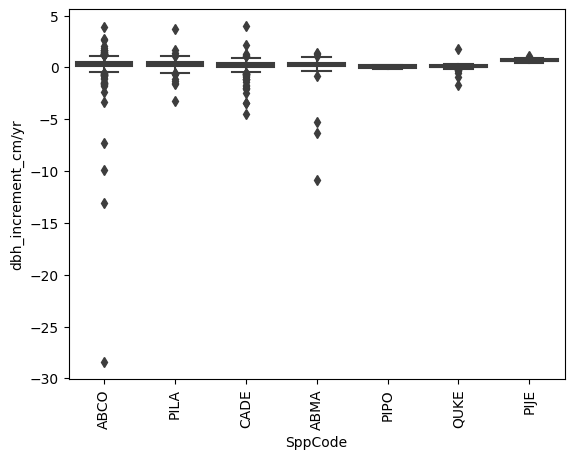

In [48]:
# Quick visualization of outliers
sns.boxplot(ddbh_df, y='dbh_increment_cm/yr', x=species_col)
plt.xticks(rotation = 90)

In [49]:
# Initial pass to identify outliers
outliers = pd.DataFrame()
sp = []
ll = []
ul = []
for s in ddbh_df[species_col].unique(): # Outliers are identified on a species basis
  sp.append(s)
  outs = id_outliers(ddbh_df, s,species_col)
  ll.append(outs[1])
  ul.append(outs[2])
  outliers = pd.concat([outliers, outs[0]])

# Create a lookup table that records the upper and lower growth limits for each species
outlier_dict = pd.DataFrame({'Species':sp,'Lower_limit':ll, 'Upper_limit':ul})
print(outlier_dict)
outliers

  Species  Lower_limit  Upper_limit
0    ABCO    -2.563837     3.166606
1    PILA    -0.974851     1.557370
2    CADE    -1.516561     1.857339
3    ABMA    -4.441097     4.528731
4    PIPO    -0.517581     0.637581
5    QUKE    -0.917930     1.024677
6    PIJE    -0.012438     1.395295


,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag
3445,FFS5BURN,FFS5BURN_4074,ABCO,2019,DBHMort,42.5,2019.0,Dead,3.0,-29.6,-9.866667,2016.0,2019.0,0
1185,FFS5BURN,FFS5BURN_4202,ABCO,2015,DBH2,68.6,2006.0,Live,5.0,19.6,3.920000,2001.0,2006.0,0
3463,FFS5BURN,FFS5BURN_4222,ABCO,2003,DBHMort,80.9,2003.0,Dead,2.0,-14.5,-7.250000,2001.0,2003.0,0
3502,FFS5BURN,FFS5BURN_4377,ABCO,2003,DBHMort,19.8,2003.0,Dead,2.0,-6.7,-3.350000,2001.0,2003.0,0
3546,FFS6BURN,FFS6BURN_1375,ABCO,2013,DBHMort,126.8,2013.0,Dead,2.0,-26.1,-13.050000,2011.0,2013.0,0
3558,FFS6BURN,FFS6BURN_4712,ABCO,2003,DBHMort,28.1,2003.0,Dead,2.0,-56.9,-28.450000,2001.0,2003.0,0
3329,FFS2BURN,FFS2BURN_1985,PILA,2003,DBHMort,22.8,2003.0,Dead,2.0,7.4,3.700000,2001.0,2003.0,0
1171,FFS5BURN,FFS5BURN_4103,PILA,2017,DBH2,71.6,2006.0,Live,5.0,-5.8,-1.160000,2001.0,2006.0,0
1798,FFS5BURN,FFS5BURN_4114,PILA,-99,DBH3,141.9,2011.0,Live,5.0,-8.0,-1.600000,2006.0,2011.0,0
1239,FFS5BURN,FFS5BURN_4453,PILA,-99,DBH2,95.6,2006.0,Live,5.0,-6.6,-1.320000,2001.0,2006.0,0


Process for removing outliers (as implemented in the `remove_outliers` function):

1. If a tree has one or more outliers in its growth timeseries, drop the first outlier in the tree’s growth timeseries.
2. Recalculate the mean annual DBH increment for the remaining records
3. Check the adjusted timeseries for outliers
4. Repeat (1-3) until all the outliers have been removed
5. Replace original growth timeseries with adjusted one
6. Log which records were dropped

Checks:
If the first growth increment is the outlier, decide whether first or second record needs to be dropped
If mean growth in first AND third interval exceed that of the mean growth between interval 1 and 3, the second record is the outlier. Otherwise, it’s the first.

In [50]:
# Flag all outliers
flagged_outliers = manage_outliers(ddbh_df, outliers, outlier_dict,species_col,
                                treeid_col, dbh_col, year_col, date_col,
                                status_col, dead_ind, date_incr)
flagged_outliers

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,0
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0,0,0
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,FFS5BURN,FFS5BURN_4217,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0
3461,FFS5BURN,FFS5BURN_4218,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0
3608,FFS7CONTROL,FFS7CONTROL_4677,ABCO,2006,DBHMort,27.8,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0,0
3651,FFS7CONTROL,FFS7CONTROL_5537,ABCO,2017,DBHMort,15.1,2017.0,Dead,NaN,NaN,NaN,NaN,2017.0,0,0


In [51]:
# Checks
# Did we retain all trees?
assert len(ddbh_df[treeid_col].unique()) == len(flagged_outliers[treeid_col].unique())

# Did we retain all records?
assert len(ddbh_df) == len(flagged_outliers)

# some extra code to sample individual trees to check
samps=random.sample(range(len(outliers[treeid_col].unique())),10)
trees_to_check = outliers[treeid_col].unique()[samps]
trees_to_check

array(['FFS6BURN_4738', 'FFS6BURN_4712', 'FFS5BURN_4222', 'FFS5BURN_4074',
       'FFS5BURN_4112', 'FFS5BURN_4453', 'FFS5BURN_4377', 'FFS5BURN_4116',
       'FFS5BURN_4454', 'FFS2BURN_5321'], dtype=object)

In [52]:
# Use this and the following cell to check random trees where we have
# manipulated DBH for the BA calculation

# Random test tree that has a growth outlier
i = 0
test = flagged_outliers.loc[flagged_outliers[treeid_col]==trees_to_check[i]].iloc[:,]
test

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier
623,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH1,38.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,1
1317,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH2,33.6,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0
1933,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH3,34.5,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0
2519,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH4,35.5,2016.0,Live,5.0,1.0,0.20,2011.0,2016.0,0,0
3049,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH5,36.2,2021.0,Live,5.0,0.7,0.14,2016.0,2021.0,0,0


In [53]:
# Test the fill_outlier function.
# Compare DBH column to DBH_BA column
# Need to use "year" column here
fill_outlier_dbh(test, dbh_col, treeid_col, year_col)

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA
623,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH1,38.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,1,32.7
1317,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH2,33.6,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0,33.6
1933,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH3,34.5,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,34.5
2519,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH4,35.5,2016.0,Live,5.0,1.0,0.20,2011.0,2016.0,0,0,35.5
3049,FFS6BURN,FFS6BURN_4738,QUKE,2022,DBH5,36.2,2021.0,Live,5.0,0.7,0.14,2016.0,2021.0,0,0,36.2


In [54]:
# Loop through all the trees that have at least one outlier record and fill the DBHs associated with those records
trees_w_outliers = flagged_outliers.loc[flagged_outliers['Outlier']==1][treeid_col].unique()

filled_outliers = pd.DataFrame()

for t in trees_w_outliers:
  tree_df = flagged_outliers.loc[flagged_outliers[treeid_col]==t]
  filled_tree = fill_outlier_dbh(tree_df, dbh_col, treeid_col, year_col)
  filled_outliers = pd.concat([filled_outliers, filled_tree])
filled_outliers

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA
15,FFS2BURN,FFS2BURN_1985,PILA,2003,DBH1,15.4,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,1,19.10
3329,FFS2BURN,FFS2BURN_1985,PILA,2003,DBHMort,22.8,2003.0,Dead,2.0,7.4,3.70,2001.0,2003.0,0,1,19.10
38,FFS2BURN,FFS2BURN_5321,ABMA,2003,DBH1,53.1,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,1,42.20
3339,FFS2BURN,FFS2BURN_5321,ABMA,2003,DBHMort,31.3,2003.0,Dead,2.0,-21.8,-10.90,2001.0,2003.0,0,1,42.20
39,FFS2BURN,FFS2BURN_5322,ABMA,2003,DBH1,32.7,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,1,26.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,FFS7CONTROL,FFS7CONTROL_5866,PILA,-99,DBH1,160.4,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,1,167.90
1598,FFS7CONTROL,FFS7CONTROL_5866,PILA,-99,DBH2,168.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0,168.90
2207,FFS7CONTROL,FFS7CONTROL_5866,PILA,-99,DBH3,169.9,2011.0,Live,5.0,1.0,0.20,2006.0,2011.0,0,0,169.90
2781,FFS7CONTROL,FFS7CONTROL_5866,PILA,-99,DBH4,171.7,2016.0,Live,5.0,1.8,0.36,2011.0,2016.0,0,0,171.70


In [55]:
# Concatenate the filled 'DBH_BA' column to the dataframe with all growth records
dbh_ts_for_ba = pd.concat([flagged_outliers, filled_outliers.loc[:,'DBH_BA']], axis=1)

# Fill the non-outlier "DBH_BA" records with their original DBH
dbh_ts_for_ba.loc[dbh_ts_for_ba['Outlier']==0, 'DBH_BA']=dbh_ts_for_ba[dbh_col]
dbh_ts_for_ba

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,0,21.2
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0,0,0,23.0
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,23.9
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0,24.0
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0,24.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,FFS5BURN,FFS5BURN_4217,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0,15.0
3461,FFS5BURN,FFS5BURN_4218,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0,15.0
3608,FFS7CONTROL,FFS7CONTROL_4677,ABCO,2006,DBHMort,27.8,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0,0,27.8
3651,FFS7CONTROL,FFS7CONTROL_5537,ABCO,2017,DBHMort,15.1,2017.0,Dead,NaN,NaN,NaN,NaN,2017.0,0,0,15.1


In [56]:
# Checks: do we have any null DBH_BA records?
assert len(dbh_ts_for_ba.loc[dbh_ts_for_ba['DBH_BA'].isnull()])==0

# Basal area timeseries

In this section, I use the tree growth data (with outliers filled for BA calculations) to develop a timeseries of plot basal area. 

In [57]:
plots = plot_raw.copy()
plots['Treatment'] = [treat_dict[i] for i in plots['Plot']]
plots

,Plot,PlotAreaActual (ha),Elevation Mean (m),Aspect Mean (Degrees),Slope Mean (Percent),Year of Establishment,Forest Type,Treatment
2,FFS6BURN,0.932,2027,170.1,26.6,2001,white fir-mixed conifer,Burn
3,FFS7CONTROL,0.984,1934,204.3,13.6,2001,white fir-mixed conifer,None
5,FFS5BURN,0.982,2014,275.3,38.1,2001,white fir-mixed conifer,Burn
7,FFS2BURN,0.978,2134,323.0,25.9,2001,white fir-mixed conifer,Burn


In [58]:
# Calculate the expansion factor for each plot
plots_per_unit = 1
plots['Expansion_factor'] = 1/(plots['PlotAreaActual (ha)']/plots_per_unit)
plots

,Plot,PlotAreaActual (ha),Elevation Mean (m),Aspect Mean (Degrees),Slope Mean (Percent),Year of Establishment,Forest Type,Treatment,Expansion_factor
2,FFS6BURN,0.932,2027,170.1,26.6,2001,white fir-mixed conifer,Burn,1.072961
3,FFS7CONTROL,0.984,1934,204.3,13.6,2001,white fir-mixed conifer,None,1.016260
5,FFS5BURN,0.982,2014,275.3,38.1,2001,white fir-mixed conifer,Burn,1.018330
7,FFS2BURN,0.978,2134,323.0,25.9,2001,white fir-mixed conifer,Burn,1.022495


In [59]:
# Merge expansion factor into tree-specific dataframe.
expansion_dct = dict(zip(plots['Plot'], plots['Expansion_factor']))
dbh_ts_for_ba['Expansion_factor'] = [expansion_dct[i] for i in dbh_ts_for_ba[unit_col]]
dbh_ts_for_ba

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA,Expansion_factor
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,0,21.2,1.01833
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0,0,0,23.0,1.01833
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,23.9,1.01833
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0,24.0,1.01833
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0,24.9,1.01833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,FFS5BURN,FFS5BURN_4217,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0,15.0,1.01833
3461,FFS5BURN,FFS5BURN_4218,ABCO,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0,15.0,1.01833
3608,FFS7CONTROL,FFS7CONTROL_4677,ABCO,2006,DBHMort,27.8,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0,0,27.8,1.01626
3651,FFS7CONTROL,FFS7CONTROL_5537,ABCO,2017,DBHMort,15.1,2017.0,Dead,NaN,NaN,NaN,NaN,2017.0,0,0,15.1,1.01626


In [60]:
# Include only live trees in BA calculation
ba_df = dbh_ts_for_ba.loc[dbh_ts_for_ba[status_col]==live_ind].copy()

# Check: do min and max DBH make sense?
ba_df.describe()

,MortalityYear,DBH,Year,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA,Expansion_factor
count,3322.000000,3322.000000,3322.000000,2245.000000,2245.000000,2245.000000,2245.000000,3322.000000,3322.0,3322.000000,3322.000000,3322.000000
mean,1139.053883,54.061376,2009.417520,5.018708,1.691938,0.338497,2008.071715,2009.417520,0.0,0.007225,54.035337,1.029382
std,1042.529292,35.682791,7.206756,0.300930,1.540968,0.306132,5.511916,7.206756,0.0,0.084703,35.668671,0.021858
min,-99.000000,15.000000,2001.000000,4.000000,-9.000000,-1.800000,2001.000000,2001.000000,0.0,0.000000,15.000000,1.016260
25%,-99.000000,25.100000,2001.000000,5.000000,0.800000,0.160000,2001.000000,2001.000000,0.0,0.000000,25.100000,1.016260
50%,2003.000000,41.800000,2011.000000,5.000000,1.500000,0.300000,2006.000000,2011.000000,0.0,0.000000,41.800000,1.018330
75%,2022.000000,75.175000,2016.000000,5.000000,2.500000,0.500000,2011.000000,2016.000000,0.0,0.000000,75.175000,1.022495
max,2023.000000,205.800000,2021.000000,10.000000,10.500000,2.100000,2016.000000,2021.000000,0.0,1.000000,205.800000,1.072961


In [61]:
# Calculate each tree's BA in square meters. Make sure to use the column with the filled DBH values.
ba_df['treeBA_m2'] = np.pi * ((ba_df.loc[:,'DBH_BA']/100)/2)**2

# Calculate the BA of each tree scaled by the expansion factor
ba_df['BAperTree_m2ha'] = ba_df.loc[:,'treeBA_m2']*ba_df.loc[:,'Expansion_factor']

ba_df

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA,Expansion_factor,treeBA_m2,BAperTree_m2ha
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,0,21.2,1.01833,0.035299,0.035946
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0,0,0,23.0,1.01833,0.041548,0.042309
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,23.9,1.01833,0.044863,0.045685
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0,24.0,1.01833,0.045239,0.046068
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0,24.9,1.01833,0.048695,0.049588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3278,FFS7CONTROL,FFS7CONTROL_5818,PILA,2022,DBH5,15.9,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,15.9,1.01626,0.019856,0.020179
3279,FFS7CONTROL,FFS7CONTROL_5823,CADE,2022,DBH5,15.0,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,15.0,1.01626,0.017671,0.017959
3304,FFS7CONTROL,FFS7CONTROL_5923,PILA,2022,DBH5,17.2,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,17.2,1.01626,0.023235,0.023613
3310,FFS7CONTROL,FFS7CONTROL_5940,PILA,2022,DBH5,16.1,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,16.1,1.01626,0.020358,0.020689


In [62]:
# Which unique years are associated with each measurement interval?
for p in ba_df['DBH_timeframe'].unique():
  print(p)
  print(ba_df.loc[ba_df['DBH_timeframe']==p, 'Year'].unique())

DBH1
[2001.]
DBH2
[2006.]
DBH3
[2011. 2012.]
DBH4
[2016.]
DBH5
[2021.]


In [63]:
# Same thing at the plot level
for i in ba_df[unit_col].unique():
  print(i)
  plot_df = ba_df.loc[ba_df[unit_col]==i]
  for p in plot_df['DBH_timeframe'].unique():
    yrs = plot_df.loc[plot_df['DBH_timeframe']==p, 'Year'].unique()
    if len(yrs)!=1:
      print(p)
      print(yrs)

FFS5BURN
FFS2BURN
DBH3
[2011. 2012.]
FFS6BURN
FFS7CONTROL
DBH3
[2011. 2012.]


To make a smooth BA timeseries, I group the measurements from DBH_timeframes with more than 1 year. 

Sequoia: for DBH3, I assign BA_year to the earlier of the two years (only one or two trees per plot were measured in 2012).

TharpsCreek: for DBH1, I assign the BA_year to 1985 (the later of the two years). For DBH7 and DBH6, I assign BA_year to the earlier of the two years (only one tree per plot was measured in 2014).

In [64]:
# Reassign DBH3 year = 2012 to 2011
ba_df['BA_year'] = ba_df['Year'].copy()

if site == 'Sequoia':
    ba_df.loc[(ba_df['Year']==2012) & (ba_df['PLOT'].isin(['FFS7CONTROL', 'FFS2BURN'])), 'BA_year'] = 2011
elif site == 'TharpsCreek':
    ba_df.loc[(ba_df['Year']==2014) & (ba_df['PLOT']=='LOTHAR'), 'BA_year'] = 2013
    ba_df.loc[(ba_df['Year']==2014) & (ba_df['PLOT']=='LOLOG'), 'BA_year'] = 2012
    ba_df.loc[(ba_df['Year']==1984) & (ba_df['PLOT']=='LOLOG'), 'BA_year'] = 1985

In [65]:
# Add a tree count for each BA year
tree_count = ba_df.groupby([unit_col,'BA_year', 'Expansion_factor'],as_index=False).agg('count')[[unit_col,'BA_year',treeid_col, 'Expansion_factor']]
tree_count['TPH'] = tree_count[treeid_col] * tree_count['Expansion_factor']
tree_count

,PLOT,BA_year,TreeID,Expansion_factor,TPH
0,FFS2BURN,2001.0,237,1.022495,242.331288
1,FFS2BURN,2006.0,157,1.022495,160.531697
2,FFS2BURN,2011.0,150,1.022495,153.374233
3,FFS2BURN,2016.0,138,1.022495,141.104294
4,FFS2BURN,2021.0,120,1.022495,122.699387
5,FFS5BURN,2001.0,244,1.018330,248.472505
6,FFS5BURN,2006.0,87,1.018330,88.594705
7,FFS5BURN,2011.0,80,1.018330,81.466395
8,FFS5BURN,2016.0,72,1.018330,73.319756
9,FFS5BURN,2021.0,53,1.018330,53.971487


In [66]:
# Calculate the plot basal area in each remeasurement year by summing the
# individual tree basal areas

ba_timeseries_unit = ba_df.groupby([unit_col, 'BA_year', 'DBH_timeframe'],
                              as_index=False, 
                             observed = True)['BAperTree_m2ha'].agg('sum')

# Merge tree count and BA
ba_timeseries_unit = pd.merge(ba_timeseries_unit, tree_count,
                         how='left', 
                         left_on=[unit_col, 'BA_year'], 
                         right_on=[unit_col, 'BA_year'])

# Add treatment
ba_timeseries_unit['Treatment'] = [treat_dict[i] for i in ba_timeseries_unit[unit_col]]

ba_timeseries_unit

,PLOT,BA_year,DBH_timeframe,BAperTree_m2ha,TreeID,Expansion_factor,TPH,Treatment
0,FFS2BURN,2001.0,DBH1,76.430617,237,1.022495,242.331288,Burn
1,FFS2BURN,2006.0,DBH2,59.861372,157,1.022495,160.531697,Burn
2,FFS2BURN,2011.0,DBH3,56.921699,150,1.022495,153.374233,Burn
3,FFS2BURN,2016.0,DBH4,51.840706,138,1.022495,141.104294,Burn
4,FFS2BURN,2021.0,DBH5,48.714461,120,1.022495,122.699387,Burn
5,FFS5BURN,2001.0,DBH1,78.145198,244,1.018330,248.472505,Burn
6,FFS5BURN,2006.0,DBH2,49.955867,87,1.018330,88.594705,Burn
7,FFS5BURN,2011.0,DBH3,48.814436,80,1.018330,81.466395,Burn
8,FFS5BURN,2016.0,DBH4,46.492371,72,1.018330,73.319756,Burn
9,FFS5BURN,2021.0,DBH5,36.325943,53,1.018330,53.971487,Burn


# Treatment intensity calculation

The intensity reduction calculation for Tharp's Creek needs to be done in two steps because the pre-post measurement years were different in the treated versus the control plots.

In [67]:
if site == 'Sequoia':
    intensity_tbl = ba_reduction(df = ba_timeseries_unit,
                            unit_col = unit_col, 
                            time_col = 'BA_year',
                            pre_ind = 2001,
                            post_ind = 2006)
elif site == 'TharpsCreek':
    ba_chng_treated = ba_reduction(df = ba_timeseries_unit.loc[ba_timeseries_unit['Treatment']!='None'],
                                  unit_col = unit_col,
                                  time_col = 'DBH_timeframe',
                                  pre_ind = 'DBH2',
                                  post_ind = 'DBH3')
    
    ba_chng_untreated = ba_reduction(df = ba_timeseries_unit.loc[ba_timeseries_unit['Treatment']=='None'],
                                  unit_col = unit_col,
                                  time_col = 'DBH_timeframe',
                                  pre_ind = 'DBH1',
                                  post_ind = 'DBH2')
    
    intensity_tbl = pd.concat([ba_chng_treated, ba_chng_untreated], ignore_index = True)

intensity_tbl

/global/home/users/jessicakatz/Repos/tree_growth_metaanalysis_snmc/Inventory_data_processing/Code/inventory_processing_functions.py:350: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ba_rdctn = (float(df.loc[(df[unit_col]==unit) & (df[time_col]==pre_ind), 'BAperTree_m2ha'])-float(df.loc[(df[unit_col]==unit) & (df[time_col]==post_ind), 'BAperTree_m2ha']))/float(df.loc[(df[unit_col]==unit) & (df[time_col]==pre_ind), 'BAperTree_m2ha'])


,UnitID,Treatment,BA_reduction
0,FFS2BURN,Burn,21.678806
1,FFS5BURN,Burn,36.073017
2,FFS6BURN,Burn,38.009901
3,FFS7CONTROL,None,2.449250


In [68]:
## Save
intensity_tbl.to_csv('Covariate_and_metaregressor_processing/Processed_data/Stand_structure/{}_intensity.csv'.format(site),
                    index = False)

# Stand density index (SDI) timeseries (imperial units)

In [69]:
## Convert metric units to imperial so that we can eventually calculate rSDI
## (Because references for max SDI are in imperial units)

## cm to inches
ba_df['DBH_in'] = ba_df['DBH_BA']/2.54

# Calculate the expansion factor for each plot
plots['Expansion_factor_imperial'] = 1/(plots['PlotAreaActual (ha)']* 2.47105)

# Merge expansion factor into tree-specific dataframe.
imprl_expansion_dct = dict(zip(plots['Plot'], plots['Expansion_factor_imperial']))
ba_df['Expansion_factor_imperial'] = [imprl_expansion_dct[i] for i in ba_df[unit_col]]
ba_df

## Calculate per tree SDI
ba_df['SDI_in'] = ba_df['Expansion_factor_imperial'] * (ba_df['DBH_in']/10)**1.6
ba_df

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA,Expansion_factor,treeBA_m2,BAperTree_m2ha,BA_year,DBH_in,Expansion_factor_imperial,SDI_in
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH1,21.2,2001.0,Live,NaN,NaN,NaN,NaN,2001.0,0,0,21.2,1.01833,0.035299,0.035946,2001.0,8.346457,0.412104,0.308610
1002,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,5.0,1.8,0.36,2001.0,2006.0,0,0,23.0,1.01833,0.041548,0.042309,2006.0,9.055118,0.412104,0.351591
1634,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,23.9,1.01833,0.044863,0.045685,2011.0,9.409449,0.412104,0.373861
2242,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0,24.0,1.01833,0.045239,0.046068,2016.0,9.448819,0.412104,0.376367
2818,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0,24.9,1.01833,0.048695,0.049588,2021.0,9.803150,0.412104,0.399201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3278,FFS7CONTROL,FFS7CONTROL_5818,PILA,2022,DBH5,15.9,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,15.9,1.01626,0.019856,0.020179,2021.0,6.259843,0.411267,0.194368
3279,FFS7CONTROL,FFS7CONTROL_5823,CADE,2022,DBH5,15.0,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,15.0,1.01626,0.017671,0.017959,2021.0,5.905512,0.411267,0.177066
3304,FFS7CONTROL,FFS7CONTROL_5923,PILA,2022,DBH5,17.2,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,17.2,1.01626,0.023235,0.023613,2021.0,6.771654,0.411267,0.220412
3310,FFS7CONTROL,FFS7CONTROL_5940,PILA,2022,DBH5,16.1,2021.0,Live,NaN,NaN,NaN,NaN,2021.0,0,0,16.1,1.01626,0.020358,0.020689,2021.0,6.338583,0.411267,0.198295


In [70]:
sdi_by_unit = ba_df.groupby([unit_col, 'BA_year'],
                              as_index=False)['SDI_in'].agg('sum')

# Add treatment
sdi_by_unit['Treatment'] = [treat_dict[i] for i in sdi_by_unit[unit_col]]

sdi_by_unit

,PLOT,BA_year,SDI_in,Treatment
0,FFS2BURN,2001.0,366.413162,Burn
1,FFS2BURN,2006.0,286.168020,Burn
2,FFS2BURN,2011.0,274.608286,Burn
3,FFS2BURN,2016.0,250.933808,Burn
4,FFS2BURN,2021.0,233.681939,Burn
5,FFS5BURN,2001.0,386.274927,Burn
6,FFS5BURN,2006.0,236.837283,Burn
7,FFS5BURN,2011.0,229.583210,Burn
8,FFS5BURN,2016.0,216.458903,Burn
9,FFS5BURN,2021.0,166.956071,Burn


## Get pre-treatment species composition

We need this to compute relative SDI.

In [71]:
# Make a dummy dataframe that includes a row for each combination of unit and year
dummy = make_dummy(ba_df, unit_col, 'BA_year')

dummy_check = ba_df.groupby([unit_col, 'BA_year'], observed = True)[treeid_col].agg('count')

# Check that all units were censused in all years
print(len(dummy)), print(len(dummy_check))

20
20


(None, None)

In [72]:
## If needed, adjust dummy to remove the plots that were not visited in a given year
dummy_all = dummy.set_index([unit_col, 'BA_year'])
to_rm = [i for i in dummy_all.index if i not in dummy_check]

to_rm

[]

In [73]:
## Make a dummy dataframe with one row for each plot-species-year combination
pft_dummy = make_pft_dummy(ba_df, unit_col, 'BA_year', species_col)
pft_dummy

,PLOT,BA_year,SppCode
0,FFS5BURN,2001.0,ABCO
1,FFS5BURN,2001.0,PILA
2,FFS5BURN,2001.0,CADE
3,FFS5BURN,2001.0,ABMA
4,FFS5BURN,2001.0,PIPO
...,...,...,...
135,FFS7CONTROL,2021.0,CADE
136,FFS7CONTROL,2021.0,ABMA
137,FFS7CONTROL,2021.0,PIPO
138,FFS7CONTROL,2021.0,QUKE


In [74]:
# Remove plots that weren't inventoried (if any)
for i in to_rm:
  pft_dummy = pft_dummy.loc[((pft_dummy[unit_col]==i[0]) & (pft_dummy['BA_year']==i[1]))==False]
pft_dummy

,PLOT,BA_year,SppCode
0,FFS5BURN,2001.0,ABCO
1,FFS5BURN,2001.0,PILA
2,FFS5BURN,2001.0,CADE
3,FFS5BURN,2001.0,ABMA
4,FFS5BURN,2001.0,PIPO
...,...,...,...
135,FFS7CONTROL,2021.0,CADE
136,FFS7CONTROL,2021.0,ABMA
137,FFS7CONTROL,2021.0,PIPO
138,FFS7CONTROL,2021.0,QUKE


In [75]:
# BA by species by plot by year
ba_by_spp = ba_df.groupby([unit_col, 'BA_year', species_col], 
                          as_index=False, 
                         observed = True)['BAperTree_m2ha'].agg('sum')
# Total plot BA by year
ba_by_spp['plot_BA'] = ba_by_spp.groupby([unit_col, 'BA_year'],
                                        observed = True)['BAperTree_m2ha'].transform('sum')
# Species fraction of plot BA
ba_by_spp['Species_frac'] = ba_by_spp['BAperTree_m2ha']/ba_by_spp['plot_BA']

ba_by_spp

,PLOT,BA_year,SppCode,BAperTree_m2ha,plot_BA,Species_frac
0,FFS2BURN,2001.0,ABCO,59.266387,76.430617,0.775427
1,FFS2BURN,2001.0,ABMA,15.462715,76.430617,0.202310
2,FFS2BURN,2001.0,PILA,1.701515,76.430617,0.022262
3,FFS2BURN,2006.0,ABCO,51.434378,59.861372,0.859225
4,FFS2BURN,2006.0,ABMA,7.324125,59.861372,0.122351
...,...,...,...,...,...,...
72,FFS7CONTROL,2016.0,CADE,23.661886,81.526156,0.290237
73,FFS7CONTROL,2016.0,PILA,21.220263,81.526156,0.260288
74,FFS7CONTROL,2021.0,ABCO,30.318646,72.131530,0.420324
75,FFS7CONTROL,2021.0,CADE,23.236816,72.131530,0.322145


In [76]:
## Merge dummy with species by plot-year
ba_by_spp_w0 = pd.merge(pft_dummy, ba_by_spp, 
                        on=[unit_col, 'BA_year', species_col], 
                        how='outer')

# Replace null values with zeroes
ba_by_spp_w0.loc[ba_by_spp_w0['Species_frac'].isnull(), 'Species_frac'] = 0
ba_by_spp_w0

,PLOT,BA_year,SppCode,BAperTree_m2ha,plot_BA,Species_frac
0,FFS2BURN,2001.0,ABCO,59.266387,76.430617,0.775427
1,FFS2BURN,2001.0,ABMA,15.462715,76.430617,0.202310
2,FFS2BURN,2001.0,CADE,NaN,NaN,0.000000
3,FFS2BURN,2001.0,PIJE,NaN,NaN,0.000000
4,FFS2BURN,2001.0,PILA,1.701515,76.430617,0.022262
...,...,...,...,...,...,...
135,FFS7CONTROL,2021.0,CADE,23.236816,72.131530,0.322145
136,FFS7CONTROL,2021.0,PIJE,NaN,NaN,0.000000
137,FFS7CONTROL,2021.0,PILA,18.576068,72.131530,0.257530
138,FFS7CONTROL,2021.0,PIPO,NaN,NaN,0.000000


In [77]:
ba_by_spp_w0.loc[ba_by_spp_w0['BA_year']<1990]

,PLOT,BA_year,SppCode,BAperTree_m2ha,plot_BA,Species_frac


In [78]:
# Extract pre-treatment compositions

# Set threshold under which measurements should be considered pre-treatment
if site == 'Sequoia':
    pre_trt_yr = 2001
elif site == 'TharpsCreek':
    pre_trt_yr = 1990

# Take the mean of pre-treatment measurement because TharpsCreek has two pre-treatment years
pretrt_comp = ba_by_spp_w0[ba_by_spp_w0['BA_year']<=pre_trt_yr].groupby([unit_col, 
                                                                         species_col], 
                                                                        as_index = False)['Species_frac'].agg('mean')
pretrt_comp.rename(columns = {unit_col: 'UnitID', species_col:'Species'},
                  inplace = True)
pretrt_comp

,UnitID,Species,Species_frac
0,FFS2BURN,ABCO,0.775427
1,FFS2BURN,ABMA,0.202310
2,FFS2BURN,CADE,0.000000
3,FFS2BURN,PIJE,0.000000
4,FFS2BURN,PILA,0.022262
5,FFS2BURN,PIPO,0.000000
6,FFS2BURN,QUKE,0.000000
7,FFS5BURN,ABCO,0.478487
8,FFS5BURN,ABMA,0.000000
9,FFS5BURN,CADE,0.214482


In [79]:
# Select necessary columns and save
pretrt_comp[['UnitID', 'Species', 'Species_frac']].to_csv('Covariate_and_metaregressor_processing/Processed_data/Stand_structure/{}_pretrt_comp.csv'.format(site),
                    index = False)


## Estimate relative SDI (rSDI) timeseries

In [80]:
sdi_tbl = make_site_sdi_table(pretrt_comp)
print(sdi_tbl['Species_frac_adj'].sum())
sdi_tbl

1.0


,Species,Species_frac,maxSDI,Species_frac_adj,SDI_x_frac
0,ABCO,0.618786,634,0.618786,392.310034
1,ABMA,0.050578,768,0.050578,38.843614
2,CADE,0.122104,576,0.122104,70.331957
3,PIJE,0.001386,497,0.001386,0.689073
4,PILA,0.190418,561,0.190418,106.824231
5,PIPO,0.005360,446,0.005360,2.390597
6,QUKE,0.011369,406,0.011369,4.615680


In [81]:
sdi_site_max = get_site_max_sdi(sdi_tbl)
sdi_site_max

np.float64(616.0051866429042)

In [82]:
rsdi_by_unit = make_rSDI_table(sdi_by_unit, sdi_site_max)
rsdi_by_unit

,PLOT,BA_year,SDI_in,Treatment,maxSDI,rSDI
0,FFS2BURN,2001.0,366.413162,Burn,616.005187,0.594822
1,FFS2BURN,2006.0,286.168020,Burn,616.005187,0.464555
2,FFS2BURN,2011.0,274.608286,Burn,616.005187,0.445789
3,FFS2BURN,2016.0,250.933808,Burn,616.005187,0.407357
4,FFS2BURN,2021.0,233.681939,Burn,616.005187,0.379351
5,FFS5BURN,2001.0,386.274927,Burn,616.005187,0.627064
6,FFS5BURN,2006.0,236.837283,Burn,616.005187,0.384473
7,FFS5BURN,2011.0,229.583210,Burn,616.005187,0.372697
8,FFS5BURN,2016.0,216.458903,Burn,616.005187,0.351391
9,FFS5BURN,2021.0,166.956071,Burn,616.005187,0.271030


In [83]:
## Remove pre-treatment measurements
rsdi = rsdi_by_unit.loc[rsdi_by_unit['BA_year']>pre_trt_yr].groupby([unit_col], 
                                                               as_index=False,
                                                              observed = True)[['SDI_in', 'maxSDI', 'rSDI']].agg('mean')
rsdi.rename(columns={'Plot':'UnitID'}, inplace = True)
rsdi

,PLOT,SDI_in,maxSDI,rSDI
0,FFS2BURN,261.348013,616.005187,0.424263
1,FFS5BURN,212.458867,616.005187,0.344898
2,FFS6BURN,169.881099,616.005187,0.275779
3,FFS7CONTROL,381.994068,616.005187,0.620115


In [84]:
## Save
rsdi.to_csv('Covariate_and_metaregressor_processing/Processed_data/Stand_structure/{}_rsdi.csv'.format(site),
                    index = False)